## 1 · Imports

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
import mlflow
import mlflow.xgboost
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
)
from lifetimes.utils import summary_data_from_transaction_data
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

/Users/ishanthakkar/Desktop/Customer_Segmentation/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 · Load Data

In [2]:
df = pd.read_parquet("../data/processed/features_segmented.parquet")
print(f"Loaded {len(df):,} customers")
df.head()

Loaded 4,290 customers


,CustomerID,Recency,Frequency,Monetary,Log_Monetary,Log_Frequency,AOV,SpendStd,PreferredDayOfWeek,WeekendRatio,...,StdGap,ReturnRate,CohortMonth,ActiveMonths,DaysSinceFirstPurchase,Recency_scaled,Log_Frequency_scaled,Log_Monetary_scaled,Segment,SegmentLabel
0,12347,2,7,4060.40,8.309283,2.079442,580.057143,351.455168,1,0.000000,...,18.478817,0.000000,2010-12,7,365,-0.905907,1.095687,1.456634,1,Loyal Customers
1,12348,75,4,1186.68,7.079757,1.609438,296.670000,225.294269,3,0.095238,...,70.149840,0.000000,2010-12,4,282,-0.175777,0.401171,0.464159,1,Loyal Customers
2,12349,19,1,1353.80,7.211409,0.693147,1353.800000,0.000000,0,0.000000,...,0.000000,0.000000,2011-11,1,0,-0.735876,-0.952816,0.570429,0,Champions
3,12350,310,1,294.40,5.688330,0.693147,294.400000,0.000000,2,0.000000,...,0.000000,0.000000,2011-02,1,0,2.174640,-0.952816,-0.659003,2,Lost / Inactive
4,12352,36,7,1385.74,7.234711,2.079442,197.962857,81.916277,1,0.000000,...,68.419296,0.909091,2011-02,4,260,-0.565846,1.095687,0.589238,1,Loyal Customers


## 3 · Principled Churn Label

**Design decision — threshold choice**

Rather than hard-coding an arbitrary 90-day cutoff, we derive the churn threshold
from the empirical inter-purchase gap distribution:

- Plot the distribution of `AvgGap` (mean days between purchases) across all customers.
- Choose the **90th percentile** as the churn threshold — customers whose inactivity
  exceeds the gap that 90 % of the population stays within are considered churned.
- This is a business-justifiable, data-driven choice rather than a magic number.

**Label leakage caveat**

The Online Retail II dataset ends at a fixed observation date. Customers who made
their last purchase close to that date will have a high `Recency` score simply because
they haven't had time to repurchase — not because they churned. We acknowledge this
limitation here; a production system would use a held-out future window to validate labels.

Data-driven churn threshold: 123 days (90th pct of AvgGap)


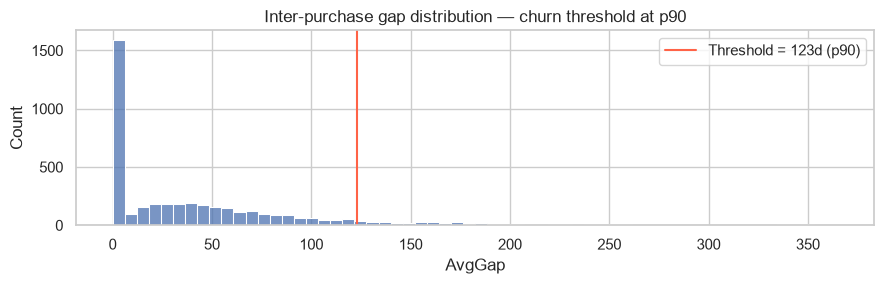

Churn rate: 27.8%  |  Churned: 1,192  |  Active: 3,098


In [3]:
# Derive threshold from the inter-purchase gap distribution
gap_col = "AvgGap" if "AvgGap" in df.columns else "Recency"
CHURN_THRESHOLD = int(np.percentile(df[gap_col].dropna(), 90))
print(f"Data-driven churn threshold: {CHURN_THRESHOLD} days (90th pct of {gap_col})")

fig, ax = plt.subplots(figsize=(9, 3))
sns.histplot(df[gap_col].dropna(), bins=60, ax=ax)
ax.axvline(CHURN_THRESHOLD, color="tomato", linewidth=1.5, label=f"Threshold = {CHURN_THRESHOLD}d (p90)")
ax.set_title(f"Inter-purchase gap distribution — churn threshold at p90")
ax.legend()
plt.tight_layout()
plt.show()

df["Churned"] = (df["Recency"] > CHURN_THRESHOLD).astype(int)
churn_rate = df["Churned"].mean()
print(f"Churn rate: {churn_rate:.1%}  |  Churned: {df['Churned'].sum():,}  |  Active: {(1 - df['Churned']).sum():,}")

## 4 · Feature Selection

**Feature leakage check — `Segment` column**

`Segment` was derived in notebook 04 using K-Means on `[Recency, Frequency, Monetary]`.
Because `Recency` directly defines our churn label, including `Segment` would leak
target information into the feature set and inflate AUC.

In a production pipeline, the segment label would be computed on a *prior* time window
and thus be non-leaky. For this research notebook we **exclude** it to keep metrics honest.

In [4]:
# Segment deliberately excluded — see leakage note above
FEATURE_COLS = [
    "Frequency", "Monetary", "AOV", "SpendStd",
    "UniqueSKUs", "RepeatSKURatio", "TotalItems",
    "AvgGap", "StdGap", "WeekendRatio",
    "PreferredDayOfWeek", "ActiveMonths",
    "DaysSinceFirstPurchase", "ReturnRate",
]

# Keep only columns that exist in the dataframe (guards against schema drift)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f"Using {len(FEATURE_COLS)} features: {FEATURE_COLS}")

X = df[FEATURE_COLS].fillna(0)
y = df["Churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Using 14 features: ['Frequency', 'Monetary', 'AOV', 'SpendStd', 'UniqueSKUs', 'RepeatSKURatio', 'TotalItems', 'AvgGap', 'StdGap', 'WeekendRatio', 'PreferredDayOfWeek', 'ActiveMonths', 'DaysSinceFirstPurchase', 'ReturnRate']


## 5 · Cross-Validation & Experiment Tracking

In [5]:
mlflow.set_experiment("churn_prediction")

model_params = dict(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="auc",
    random_state=42,
)

cv_model = xgb.XGBClassifier(**model_params)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"CV ROC-AUC:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold:    {np.round(cv_scores, 4)}")

2026/06/27 02:34:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/27 02:34:51 INFO mlflow.store.db.utils: Updating database tables
2026/06/27 02:34:52 INFO mlflow.tracking.fluent: Experiment with name 'churn_prediction' does not exist. Creating a new experiment.


CV ROC-AUC:  0.8004 ± 0.0086
Per-fold:    [0.7947 0.8043 0.8147 0.7985 0.7898]


## 6 · Train Final Model

In [6]:
model = xgb.XGBClassifier(**model_params)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]

# F1-optimal threshold
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba)
# Avoid divide-by-zero; epsilon guards the degenerate precision=recall=0 edge
f1_arr = (
    2 * precision_arr[:-1] * recall_arr[:-1]
    / (precision_arr[:-1] + recall_arr[:-1] + 1e-9)
)
THRESHOLD = float(thresholds_arr[np.argmax(f1_arr)])

y_pred_default = (y_proba > 0.5).astype(int)
y_pred = (y_proba > THRESHOLD).astype(int)

print(f"Default threshold (0.50) F1 : {f1_score(y_test, y_pred_default):.4f}")
print(f"Optimal threshold ({THRESHOLD:.3f}) F1 : {f1_score(y_test, y_pred):.4f}")

Default threshold (0.50) F1 : 0.6225
Optimal threshold (0.479) F1 : 0.6278


## 7 · Evaluation

              precision    recall  f1-score   support

           0       0.91      0.70      0.79       620
           1       0.51      0.82      0.63       238

    accuracy                           0.73       858
   macro avg       0.71      0.76      0.71       858
weighted avg       0.80      0.73      0.75       858

ROC-AUC  : 0.8230
Accuracy : 0.7319
Precision: 0.5105
Recall   : 0.8151
F1       : 0.6278


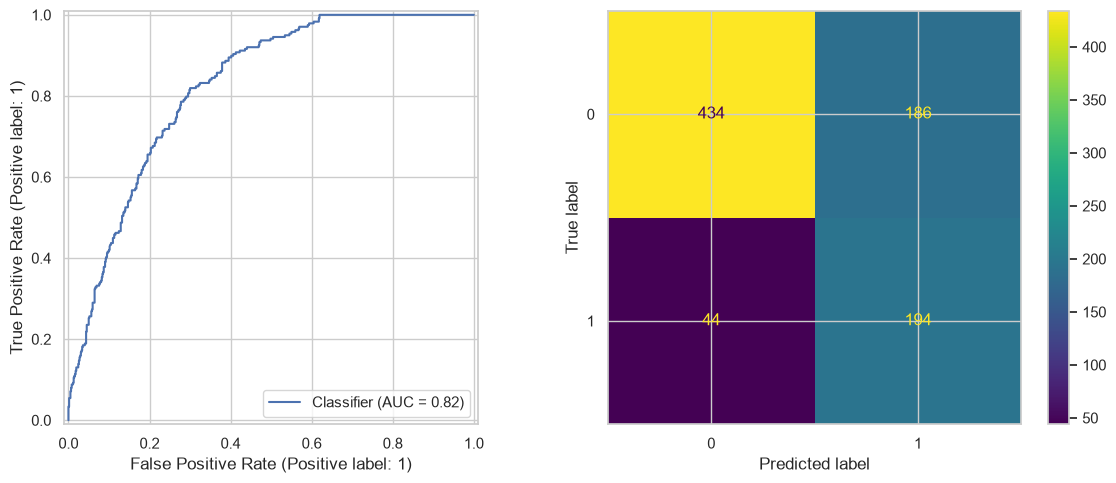

In [7]:
roc_auc = roc_auc_score(y_test, y_proba)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[1])
plt.tight_layout()
plt.show()

## 8 · Explainability

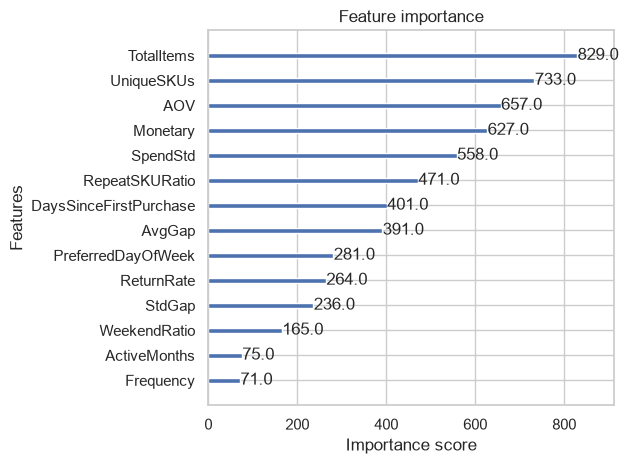

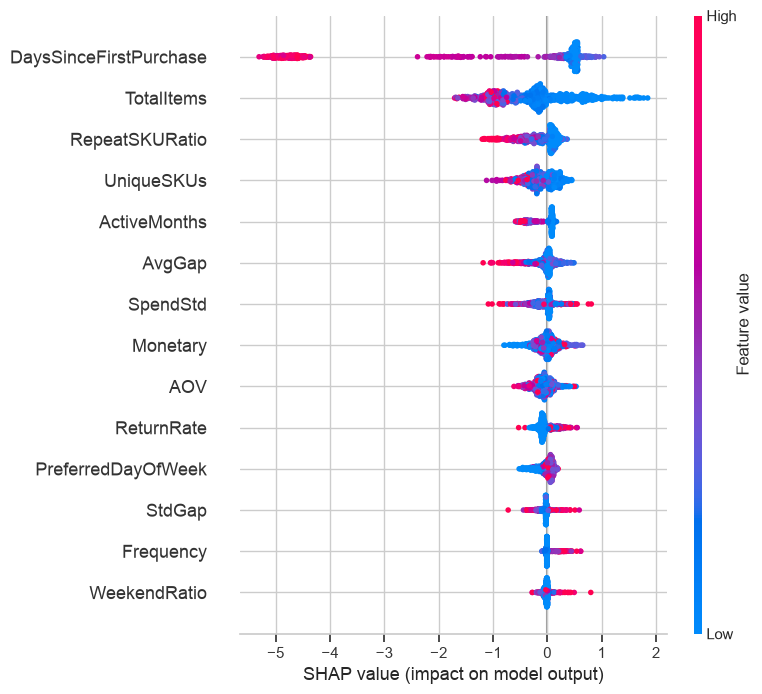

In [8]:
xgb.plot_importance(model, max_num_features=15)
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

## 9 · Log to MLflow & Save Churn Artefacts

We persist **three artefacts** together so that any downstream inference service
can reconstruct exactly the same prediction logic without referencing this notebook:

| Artefact | Purpose |
|---|---|
| `churn_xgb.joblib` | Trained model weights |
| `churn_config.json` | Threshold, feature list, churn definition |
| MLflow run | Params, metrics, CV scores, model registry entry |

In [9]:
ARTEFACT_DIR = Path("../models/artifacts")
ARTEFACT_DIR.mkdir(parents=True, exist_ok=True)

# Add churn probability to the main dataframe
df["ChurnProb"] = model.predict_proba(X)[:, 1]

# --- Inference config (threshold + feature list must travel with the model) ---
model_config = {
    "threshold": THRESHOLD,
    "feature_cols": FEATURE_COLS,
    "churn_threshold_days": CHURN_THRESHOLD,
    "churn_definition": "Recency > churn_threshold_days",
    "label_leakage_note": (
        "Segment column excluded — it encodes Recency which defines the churn label. "
        "Re-include only if Segment is computed on a prior observation window."
    ),
}

model_path = ARTEFACT_DIR / "churn_xgb.joblib"
config_path = ARTEFACT_DIR / "churn_config.json"

joblib.dump(model, model_path)
config_path.write_text(json.dumps(model_config, indent=2))
print(f"Model  → {model_path}")
print(f"Config → {config_path}")
print(json.dumps(model_config, indent=2))

# --- MLflow logging ---
with mlflow.start_run(run_name="xgb_churn_v1"):
    mlflow.log_params({
        **{k: v for k, v in model_params.items() if k != "scale_pos_weight"},
        "scale_pos_weight": round(model_params["scale_pos_weight"], 3),
        "churn_threshold_days": CHURN_THRESHOLD,
        "n_features": len(FEATURE_COLS),
        "decision_threshold": round(THRESHOLD, 4),
    })
    mlflow.log_metrics({
        "cv_roc_auc_mean": round(cv_scores.mean(), 4),
        "cv_roc_auc_std": round(cv_scores.std(), 4),
        "test_roc_auc": round(roc_auc, 4),
        "test_accuracy": round(accuracy, 4),
        "test_precision": round(precision, 4),
        "test_recall": round(recall, 4),
        "test_f1": round(f1, 4),
    })
    mlflow.log_artifact(str(config_path))
    mlflow.xgboost.log_model(model, artifact_path="churn_xgb")
    run_id = mlflow.active_run().info.run_id

print(f"\nMLflow run logged: {run_id}")

2026/06/27 02:34:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model  → ../models/artifacts/churn_xgb.joblib
Config → ../models/artifacts/churn_config.json
{
  "threshold": 0.47932055592536926,
  "feature_cols": [
    "Frequency",
    "Monetary",
    "AOV",
    "SpendStd",
    "UniqueSKUs",
    "RepeatSKURatio",
    "TotalItems",
    "AvgGap",
    "StdGap",
    "WeekendRatio",
    "PreferredDayOfWeek",
    "ActiveMonths",
    "DaysSinceFirstPurchase",
    "ReturnRate"
  ],
  "churn_threshold_days": 123,
  "churn_definition": "Recency > churn_threshold_days",
  "label_leakage_note": "Segment column excluded \u2014 it encodes Recency which defines the churn label. Re-include only if Segment is computed on a prior observation window."
}

MLflow run logged: a217011ee7124c14b48262241325cbad


In [10]:
raw = pd.read_parquet("../data/interim/cleaned.parquet")
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"])

# Remove returns/refunds — negative Revenue violates BG/NBD + GGF assumptions
n_before = len(raw)
raw = raw[raw["Revenue"] > 0].copy()
print(f"Removed {n_before - len(raw):,} return/refund rows ({(n_before - len(raw)) / n_before:.1%})")

OBSERVATION_END = raw["InvoiceDate"].max()
print(f"Observation period end: {OBSERVATION_END.date()}")

summary = summary_data_from_transaction_data(
    raw,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    monetary_value_col="Revenue",
    observation_period_end=OBSERVATION_END,
)

# GGF requires repeat customers (frequency > 0)
n_total = len(summary)
summary = summary[summary["frequency"] > 0]
print(f"Repeat customers: {len(summary):,} / {n_total:,} ({len(summary)/n_total:.1%})")

Removed 0 return/refund rows (0.0%)
Observation period end: 2011-12-09
Repeat customers: 2,744 / 4,290 (64.0%)


## 11 · GGF Independence Assumption Check

The Gamma-Gamma model assumes purchase frequency and average spend are **uncorrelated**.
We verify this before fitting and warn if the assumption is materially violated.

## 12 · BG/NBD & Gamma-Gamma Fitting

## 15 · Visualisations

## 16 · Save Final Feature Store